In [1]:
from ucimlrepo import fetch_ucirepo 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance


### Business Understanding

The goal is to construt two separate models for predicting the real estate prices in the dataset: one with linear and one with logistic regression.


### Data Understanding

The data is imported from `https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set` and is imported via python ucimlrepo.

The data consists of inputs such as proximity to the nearest MRT station, house age and number of stores in the living circle. The output Y is the house price of unit area. 1 PING = 3.3m^2. The data has no missing values.


The inputs are as follows
- X1=the transaction date (for example, 2013.250=2013 March, 2013.500=2013 June, etc.)
- X2=the house age (unit: year)
- X3=the distance to the nearest MRT station (unit: meter)
- X4=the number of convenience stores in the living circle on foot (integer)
- X5=the geographic coordinate, latitude. (unit: degree)
- X6=the geographic coordinate, longitude. (unit: degree)



The output is as follow
- Y= house price of unit area (10000 New Taiwan Dollar/Ping, where Ping is a local unit, 1 Ping = 3.3 meter squared)

Using this data we are able to construct a regression model to predict the price according to the input features above.

### Data Preparation

For the logistic regression model to work and to build it, we calculate the average house price of unit area for the binary classifier. The input values are also standardized for the logistic regression model. For the linear regression model, no changes are needed.

In [2]:
df = fetch_ucirepo(id=477)
X = df.data.features
y = df.data.targets

X.head(20)

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245
5,2012.667,7.1,2175.03000,3,24.96305,121.51254
6,2012.667,34.5,623.47310,7,24.97933,121.53642
7,2013.417,20.3,287.60250,6,24.98042,121.54228
8,2013.500,31.7,5512.03800,1,24.95095,121.48458
9,2013.417,17.9,1783.18000,3,24.96731,121.51486


The columns are on very different scales. Without standardization, the features with the largest numeric ranges would dominate the model. So the data is standardized to put every feature on a comparable scale.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

average_price = y_train['Y house price of unit area'].mean()
print("Average house price of unit area:", average_price)

y_train_binary = (y_train['Y house price of unit area'] > average_price).astype(int)
y_test_binary  = (y_test['Y house price of unit area']  > average_price).astype(int)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled  = scaler.transform(X_test)    

Average house price of unit area: 38.39154078549849


### Modeling
The linear- and logistic regression models are created and tested using sklearn's library.

In [4]:
#Linear Regression Model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 6)","[[ 5.44, -0.27, -0. , 1.09,229.04,-29.49]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['X1 transaction date','X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores','X5 latitude','X6 longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-13044.23]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [5]:
#Regression Model
reg_model = LogisticRegression(solver='lbfgs')
reg_model.fit(X_train_scaled, y_train_binary)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

### Evaluation
After building the models, we evaluate the correctness of each model's outputs. We used confusion matrices for visualization. For metrics we calcualted the mean absolute error.

Mean Absolute Error (Linear Regression): 5.305355690074118

Confusion Matrix (Logistic Regression):


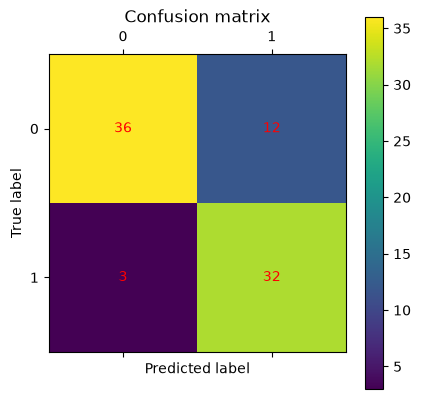

In [6]:
# Evaluate the linear regression model
y_pred = lin_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (Linear Regression):", mae)

# Evaluate the logistic regression model
y_pred_binary = reg_model.predict(X_test_scaled)
cm = confusion_matrix(y_test_binary, y_pred_binary)
print("")
print("Confusion Matrix (Logistic Regression):")
plt.matshow(cm)
plt.title('Confusion matrix')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
# include counts
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red')
plt.show()

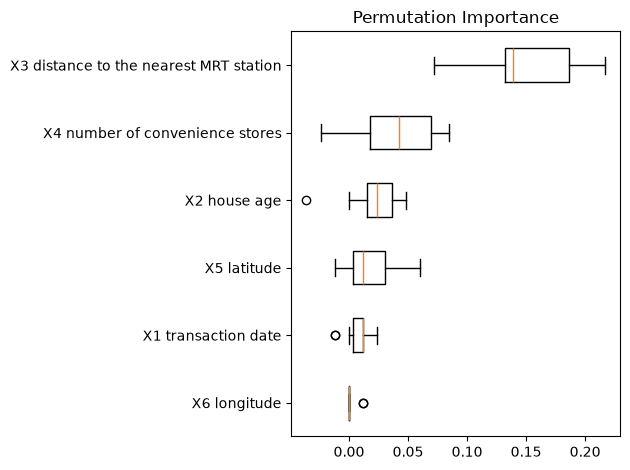

In [7]:
# Regression model feature importance
result = permutation_importance(reg_model, X_test_scaled, y_test_binary, n_repeats=10, random_state=0, n_jobs=-1)
importance = result.importances_mean.argsort()

fig, ax = plt.subplots()
ax.boxplot(result.importances[importance].T, orientation='horizontal', tick_labels=X.columns[importance])
ax.set_title("Permutation Importance")
fig.tight_layout()
plt.show()

In [8]:
# Calculate accuracy score for logistic regression
acc_test_logistic = accuracy_score(y_test_binary, y_pred_binary)
print("Accuracy Score (Logistic Regression):", acc_test_logistic)

Accuracy Score (Logistic Regression): 0.8192771084337349


For the linear regression model we achieved a mean absolute error of 5.3, meaning the predicted price differs from the actual price by about 5.3 pings on average roughly 14% of the mean price of 37.9.

For the logistic regression model, recall was about 75% for class 0 (below-average price) and about 91.4% for class 1 (above-average price), giving an overall accuracy of 82% on the test set. The model is noticeably better at identifying above-average properties than below-average ones.

We can see from the permutation importance that the distance to the nearest MRT-station had the most impact on the price of the real estate, and secondly the amount of convience stores also impacted the price. 

### Deployment

The linear model can be used to predict the house price of unit area (PINGS), with an accuracy of ±13.9% (MAE 5.27). The regression model predicts if a house will be priced below average or above average with a success rate of about 82%.